Análisis exploratorio de datos

### Importación de librerías

In [11]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import math

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 10)

# Lectura de los datos
ROOT = Path("..") 
data_path = ROOT / "data" / "processed" / "temporada1_limpio.parquet"
data = pl.read_parquet(data_path)

### Carga de datos y reporte automático con *sweetviz*

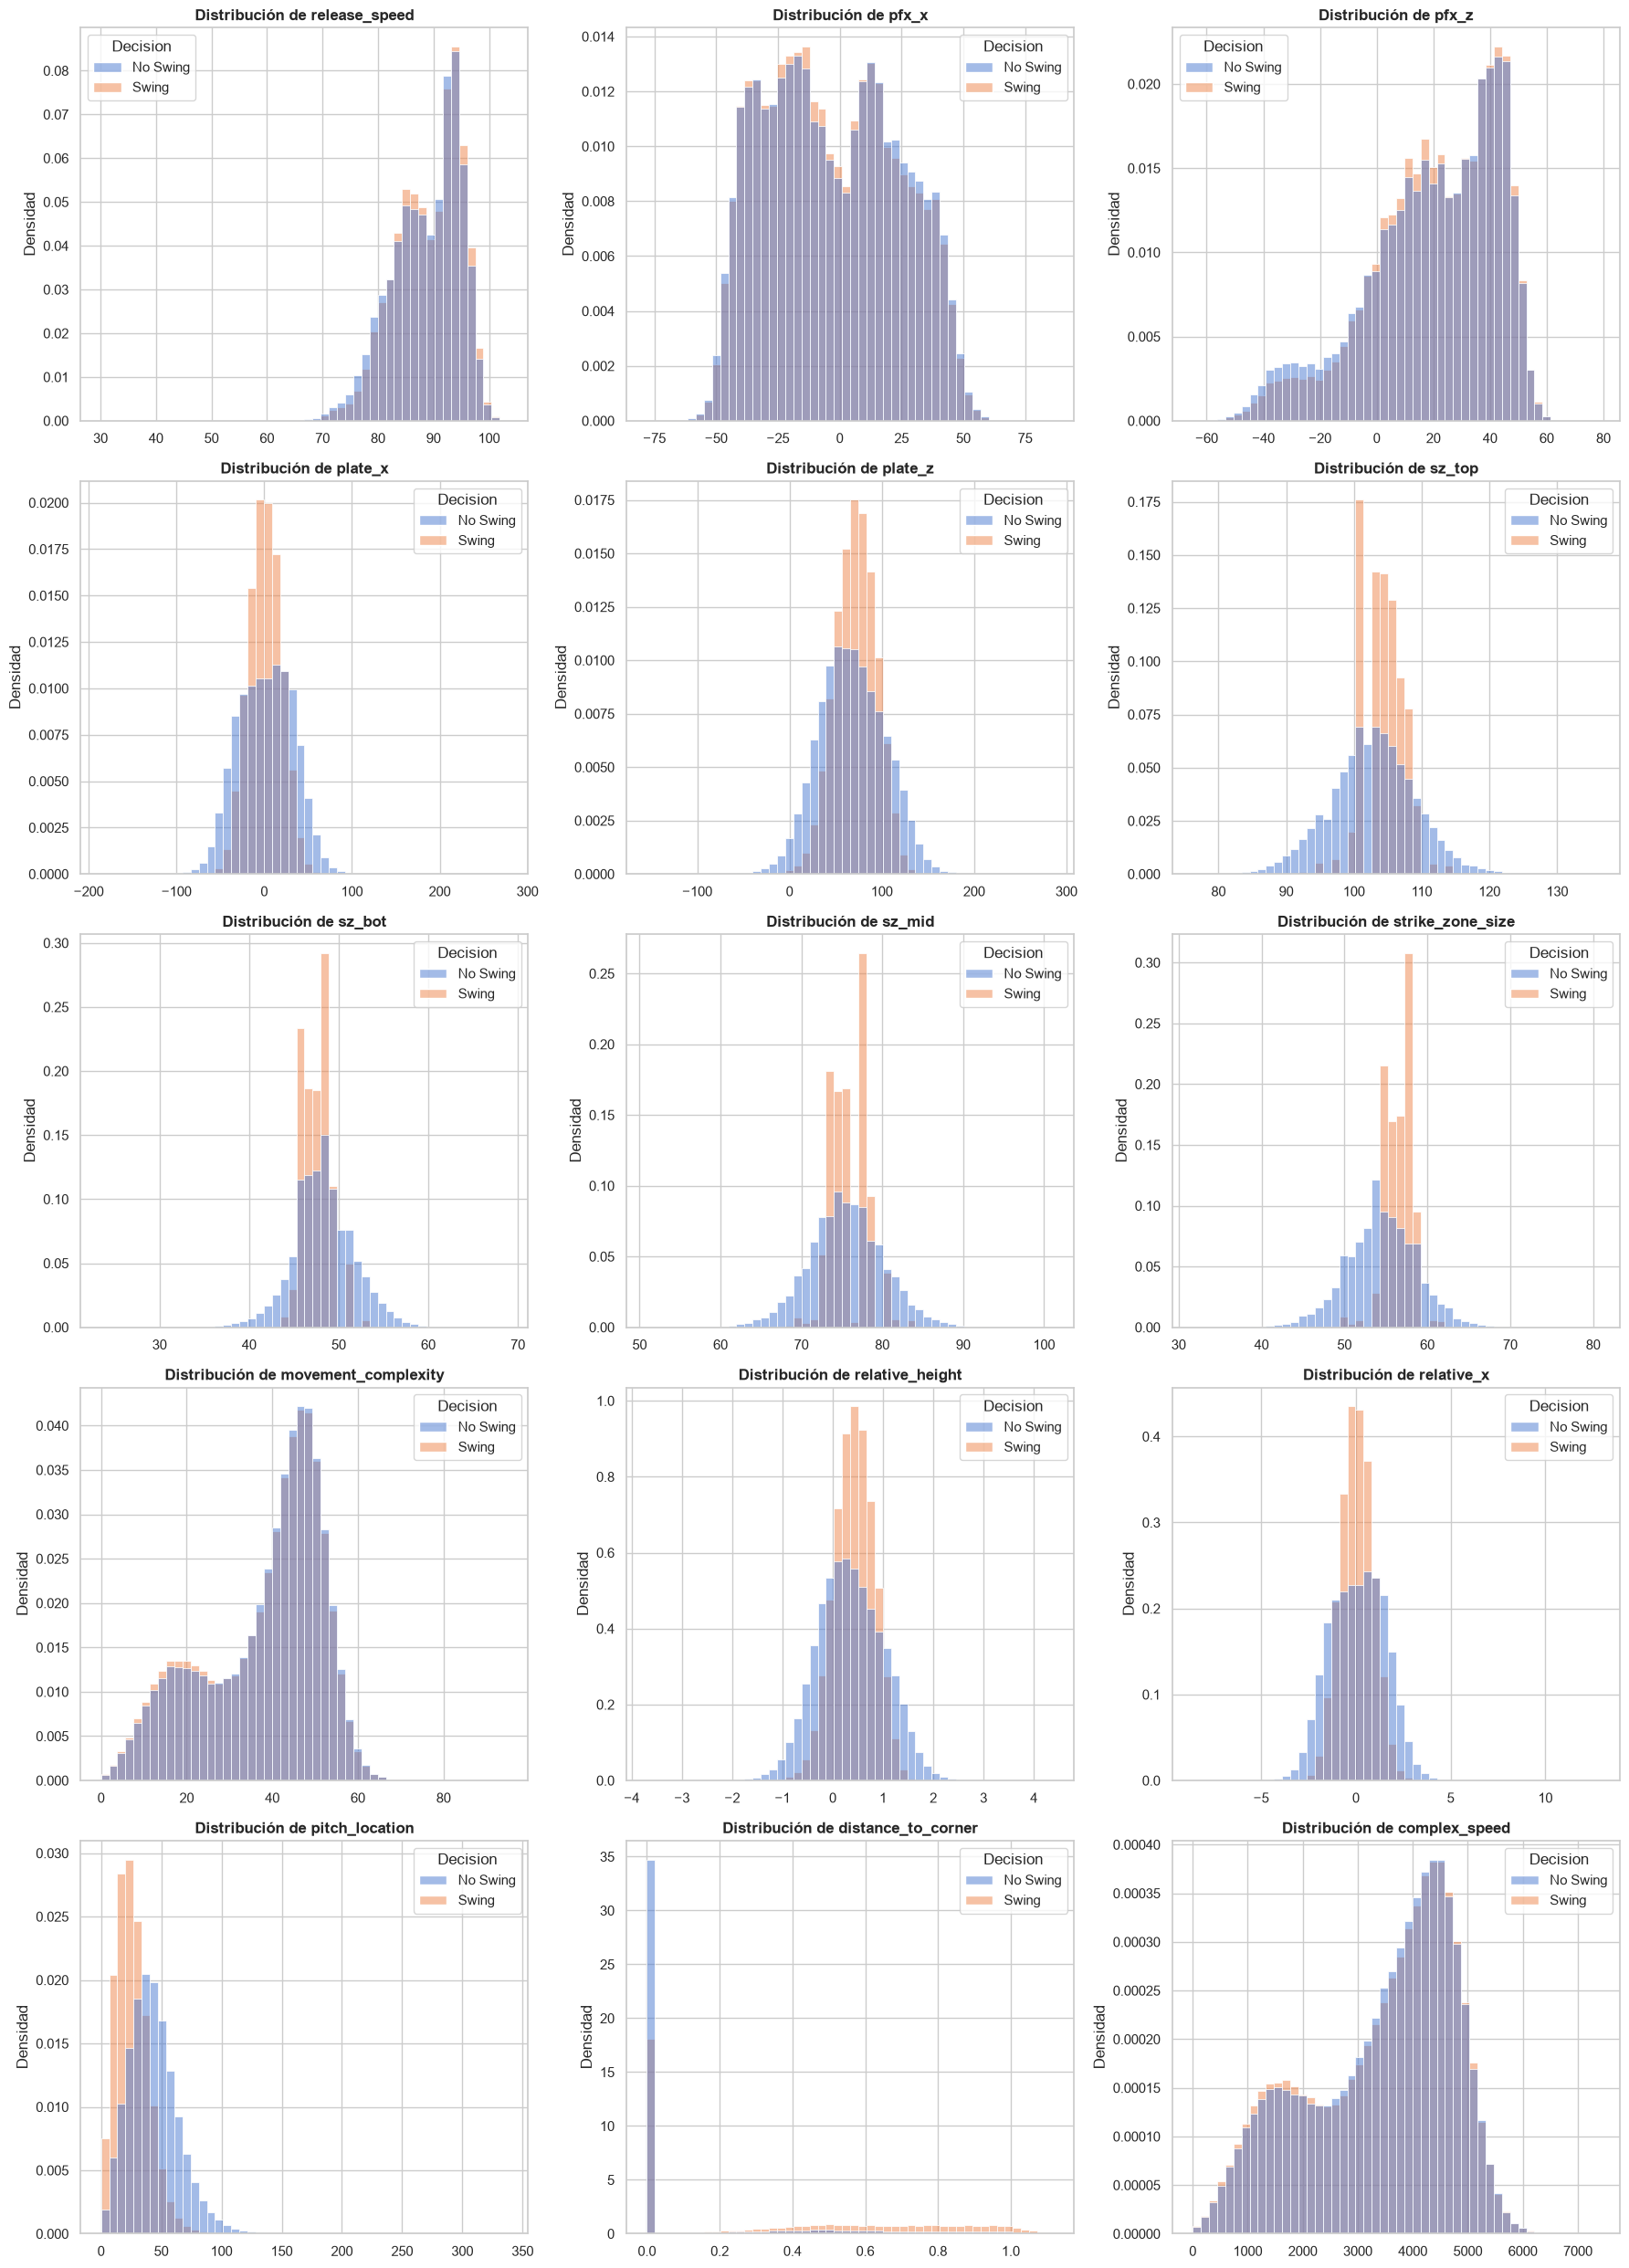

In [ ]:
df_pandas = data.to_pandas()

# Creamos una columna de texto para que las leyendas del gráfico sean más claras
df_pandas['Decision'] = df_pandas['swing'].map({1: 'Swing', 0: 'No Swing'})

# Variables discretas o de identificación, que no tiene sentido analizar (como pitch_id)
columnas_a_excluir = [
    'pitch_id', 'batter', 'pitcher', 'swing', 'Decision',
    'balls', 'strikes', 'platoon_advantage', 'is_strike_zone', 'is_shadow_zone'
]

# Seleccionamos solo las columnas continuas
variables_numericas = [
    col for col in df_pandas.select_dtypes(include=['number']).columns 
    if col not in columnas_a_excluir
]

# Creamos la grilla para graficar
n_cols = 3
n_rows = math.ceil(len(variables_numericas) / n_cols)

# El alto de la figura crece automáticamente (5 pulgadas por cada fila)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Iteración para graficar
for i, var in enumerate(variables_numericas):
    sns.histplot(
        data=df_pandas, 
        x=var, 
        hue="Decision", 
        stat="density", 
        common_norm=False, 
        bins=50, 
        alpha=0.5, 
        ax=axes[i]
    )
    axes[i].set_title(f'Distribución de {var}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel("") 
    axes[i].set_ylabel("Densidad")

plt.tight_layout()
plt.show()

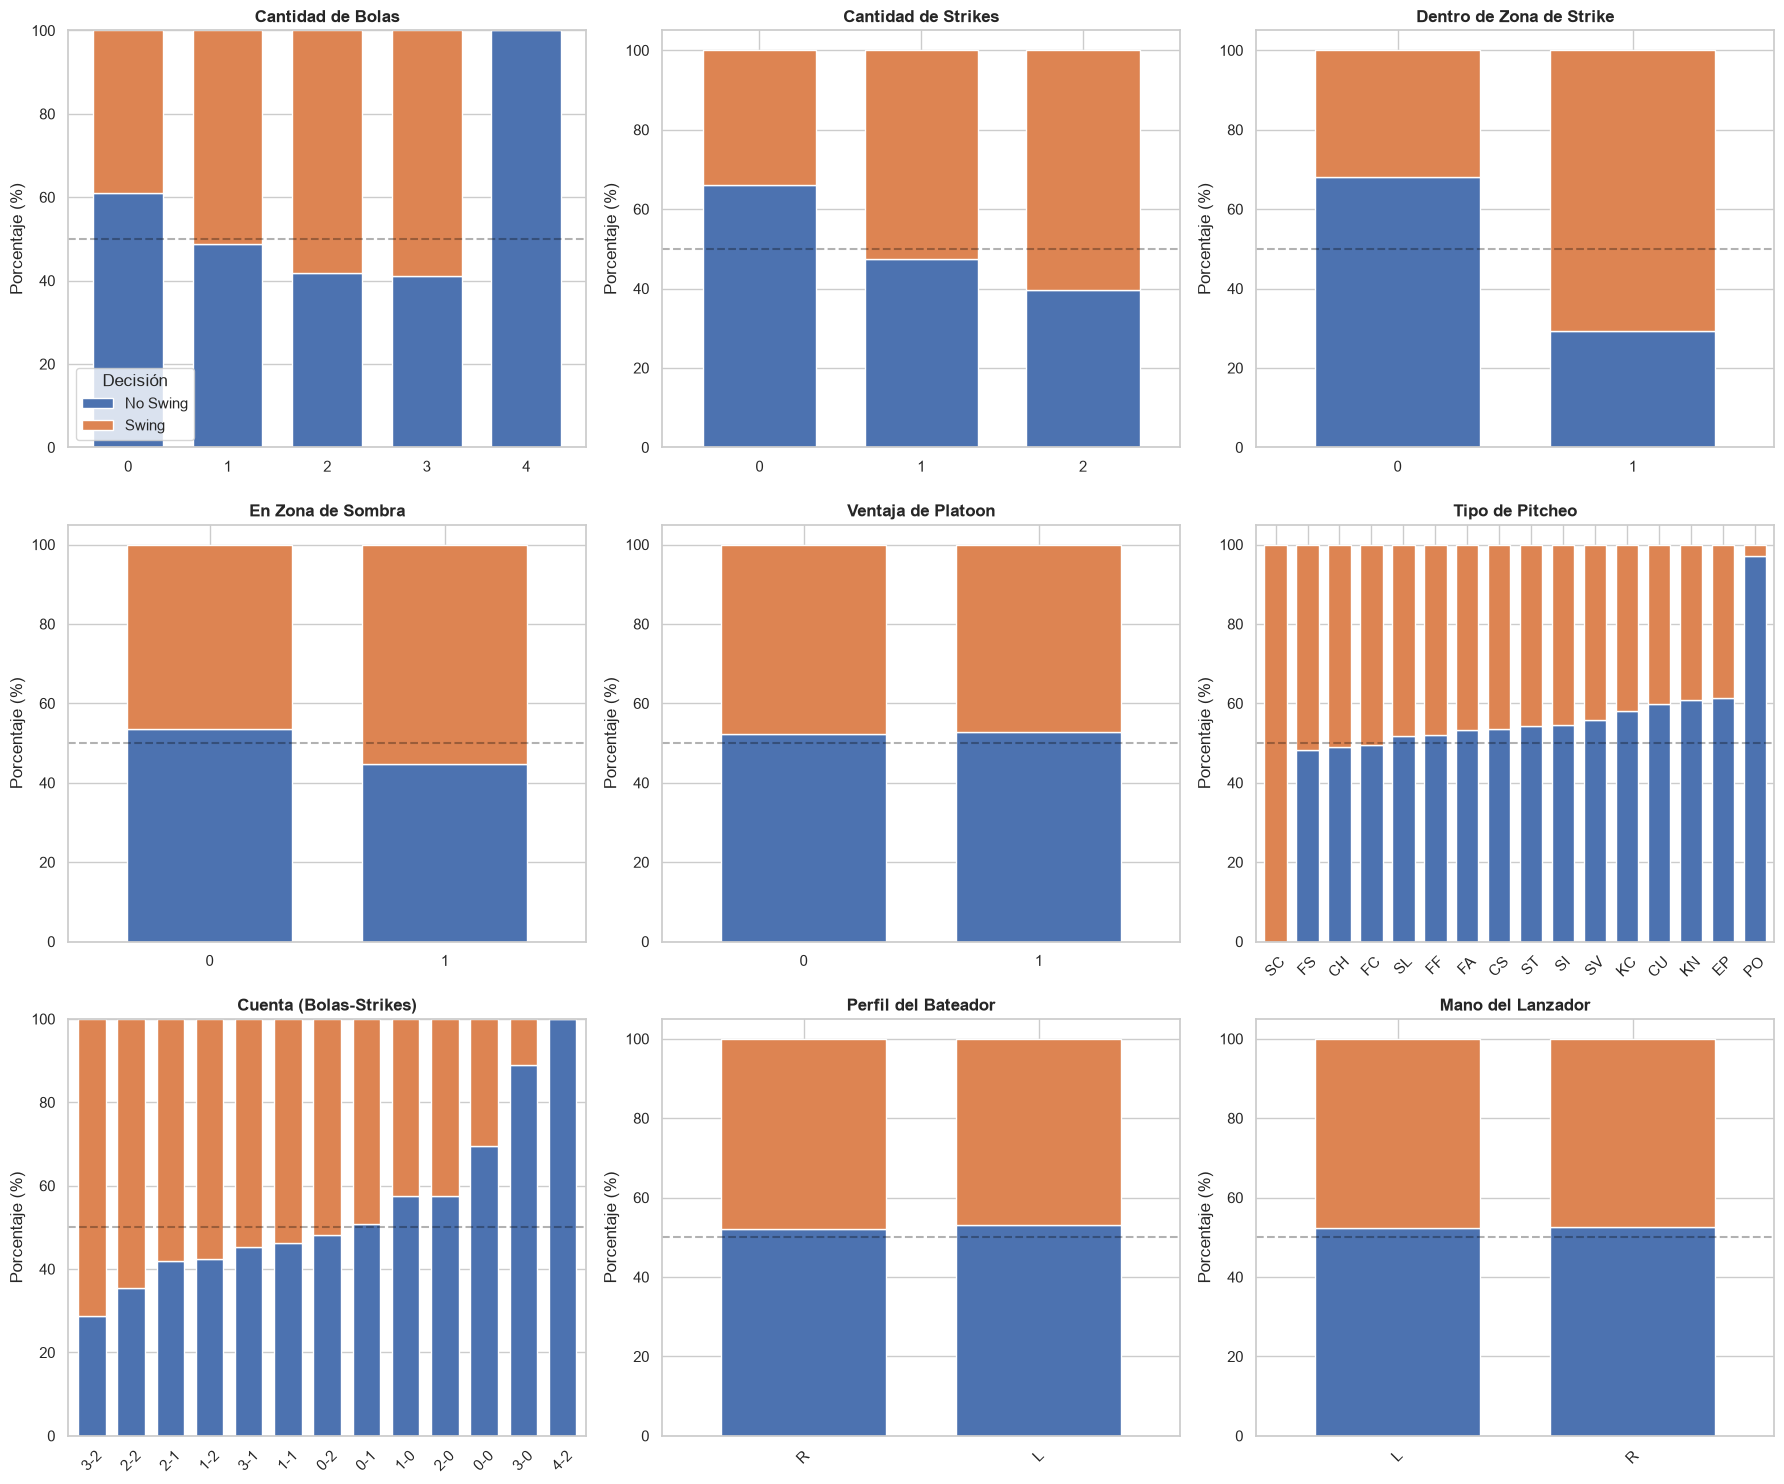

In [ ]:
# Variables discretas (algunas figuran como numéricas en el dataset)
vars_ordinales = ['balls', 'strikes', 'is_strike_zone', 'is_shadow_zone', 'platoon_advantage']
vars_nominales = ['pitch_type', 'count', 'stand', 'p_throws']

todas_las_variables = vars_ordinales + vars_nominales
titulos = [
    'Cantidad de Bolas', 'Cantidad de Strikes', 'Dentro de Zona de Strike', 
    'En Zona de Sombra', 'Ventaja de Platoon', 'Tipo de Pitcheo', 
    'Cuenta (Bolas-Strikes)', 'Perfil del Bateador', 'Mano del Lanzador'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, var in enumerate(todas_las_variables):
    # Calculamos las proporciones
    tabla_prop = pd.crosstab(df_pandas[var], df_pandas['Decision'], normalize='index') * 100
    
    # Si es una variable nominal y existe la columna 'Swing', la ordenamos por tasa de Swing
    if var in vars_nominales and 'Swing' in tabla_prop.columns:
        tabla_prop = tabla_prop.sort_values(by='Swing', ascending=False)
    
    # Graficamos
    tabla_prop.plot(
        kind='bar', 
        stacked=True, 
        ax=axes[i], 
        color=['#4C72B0', '#DD8452'], 
        width=0.7,
        edgecolor='white'
    )
    
    axes[i].set_title(f'{titulos[i]}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Porcentaje (%)")
    
    # Si es una variable con mucho texto (como count o pitch_type), rotamos las etiquetas
    if var in vars_nominales:
        axes[i].tick_params(axis='x', rotation=45)
    else:
        axes[i].tick_params(axis='x', rotation=0)
    
    # Dejamos la leyenda solo en el primer gráfico, para no saturar
    if i == 0:
        axes[i].legend(title='Decisión', loc='lower left')
    else:
        axes[i].get_legend().remove()
        
    # Línea de referencia del 50%
    axes[i].axhline(50, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Medidas descriptivas

In [21]:
print("--- MEDIAS DE LAS VARIABLES CONTINUAS ---")
expresiones_media = [
    pl.col(var).mean().round(2).alias(f"media_{var}") 
    for var in variables_numericas
]

resumen_continuas = data.group_by("swing").agg(expresiones_media).sort("swing")
display(resumen_continuas)


print("\n--- TASA DE SWING POR ZONA Y TAMAÑO DE MUESTRA ---")
# Combinar zona reglamentaria y zona de sombra da el panorama completo
analisis_zonas = data.group_by("is_strike_zone", "is_shadow_zone").agg([
    pl.len().alias("cantidad_lanzamientos"),
    (pl.col("swing").mean() * 100).round(1).alias("tasa_de_swing_(%)")
]).sort("tasa_de_swing_(%)", descending=True)
display(analisis_zonas)


print("\n--- TASA DE SWING SEGÚN LA CUENTA ---")
analisis_cuenta = data.group_by("count").agg([
    pl.len().alias("cantidad_lanzamientos"),
    (pl.col("swing").mean() * 100).round(1).alias("tasa_de_swing_(%)")
]).sort("tasa_de_swing_(%)", descending=True)
display(analisis_cuenta)

--- MEDIAS DE LAS VARIABLES CONTINUAS ---


swing,media_release_speed,media_pfx_x,media_pfx_z,media_plate_x,media_plate_z,media_sz_top,media_sz_bot,media_sz_mid,media_strike_zone_size,media_movement_complexity,media_relative_height,media_relative_x,media_pitch_location,media_distance_to_corner,media_complex_speed
i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,88.67,-2.98,19.44,1.88,67.52,102.75,48.29,75.52,54.46,38.1,0.36,0.09,43.3,0.13,3408.91
1,89.05,-3.38,20.68,0.77,71.36,104.09,47.62,75.85,56.47,37.7,0.42,0.04,25.85,0.38,3388.49



--- TASA DE SWING POR ZONA Y TAMAÑO DE MUESTRA ---


is_strike_zone,is_shadow_zone,cantidad_lanzamientos,tasa_de_swing_(%)
i32,i32,u32,f64
1,0,282140,70.7
0,1,88801,55.2
0,0,333780,25.8



--- TASA DE SWING SEGÚN LA CUENTA ---


count,cantidad_lanzamientos,tasa_de_swing_(%)
str,u32,f64
"""3-2""",35024,71.2
"""2-2""",58237,64.6
"""2-1""",37000,58.0
"""1-2""",67755,57.5
"""3-1""",15594,54.7
…,…,…
"""1-0""",70447,42.5
"""2-0""",24200,42.5
"""0-0""",180276,30.4
